# ⚡ Power Consumption Forecasting 📈
This notebook focuses on forecasting the **Global Active Power** using various Time Series forecasting techniques. 

We will explore and compare the following models:
- **Manual ARIMA** (Autoregressive Integrated Moving Average)
- **Auto ARIMA**
- **SARIMA** (Seasonal ARIMA)
- **Prophet** (by Meta)

Let's begin by importing the necessary libraries and configuring the visual aesthetics.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from statsmodels.tsa.arima.model import ARIMA
from statsmodels.tsa.statespace.sarimax import SARIMAX
from prophet import Prophet
from sklearn.metrics import (mean_absolute_error, mean_squared_error, mean_absolute_percentage_error)
from pmdarima import auto_arima
import joblib
import os

## 📂 1. Data Loading & Inspection
We load the cleaned dataset saved in parquet format. This data contains the recording of power consumption over time.

In [4]:
df = pd.read_parquet("cleaned_power.parquet")
df.head()

,Global_active_power,Global_reactive_power,Voltage,Global_intensity,Sub_metering_1,Sub_metering_2,Sub_metering_3
2006-12-16 17:24:00,4.216,0.418,234.839996,18.4,0.0,1.0,17.0
2006-12-16 17:25:00,5.360,0.436,233.630005,23.0,0.0,1.0,16.0
2006-12-16 17:26:00,5.374,0.498,233.289993,23.0,0.0,2.0,17.0
2006-12-16 17:27:00,5.388,0.502,233.740005,23.0,0.0,1.0,17.0
2006-12-16 17:28:00,3.666,0.528,235.679993,15.8,0.0,1.0,17.0


Let's check the data types, number of entries, and memory usage of our dataset.

In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
DatetimeIndex: 2075259 entries, 2006-12-16 17:24:00 to 2010-11-26 21:02:00
Data columns (total 7 columns):
 #   Column                 Dtype  
---  ------                 -----  
 0   Global_active_power    float32
 1   Global_reactive_power  float32
 2   Voltage                float32
 3   Global_intensity       float32
 4   Sub_metering_1         float32
 5   Sub_metering_2         float32
 6   Sub_metering_3         float32
dtypes: float32(7)
memory usage: 71.2 MB


## 🔄 2. Data Resampling
Time series forecasting requires data to be at a consistent frequency. We will resample our data to an **Hourly (`h`)** frequency and take the mean of `Global_active_power`.

In [6]:
ts = df["Global_active_power"].resample("h").mean()
ts.head()

2006-12-16 17:00:00    4.222889
2006-12-16 18:00:00    3.632200
2006-12-16 19:00:00    3.400233
2006-12-16 20:00:00    3.268567
2006-12-16 21:00:00    3.056467
Freq: h, Name: Global_active_power, dtype: float32

## 📊 3. Exploratory Data Analysis (EDA)
Let's visualize the historical trend of Global Active Power to observe any noticeable patterns, seasonality, or anomalies.

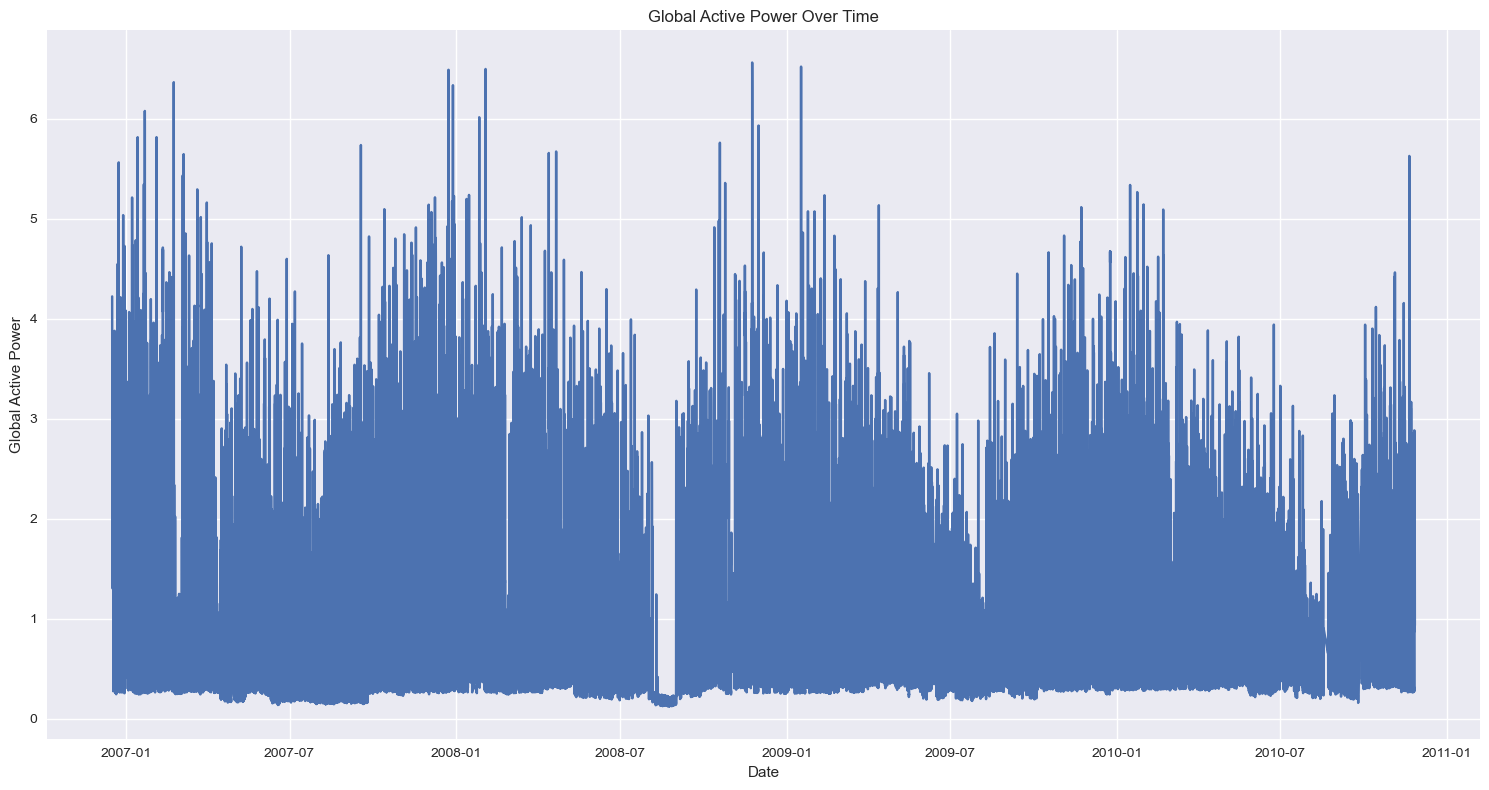

In [7]:
plt.figure(figsize=(15,8))
plt.plot(ts)
plt.title("Global Active Power Over Time")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.tight_layout()
plt.show()

## ✂️ 4. Train/Test Split
To evaluate our forecasting models, we need to split our dataset. We will use the first **80%** of the data for training and the remaining **20%** for testing our models' predictive performance.

In [8]:
split = int(len(ts) * 0.8)
train = ts.iloc[:split]
test = ts.iloc[split:]

## 📉 5. Checking for Stationarity (ADF Test)
ARIMA and SARIMA models assume that the time series is **stationary** (statistical properties like mean and variance are constant over time). We use the **Augmented Dickey-Fuller (ADF)** test to check this.
- **Null Hypothesis (H0):** The series has a unit root (is non-stationary).
- **Alternative Hypothesis (H1):** The series has no unit root (is stationary).

In [9]:
adf_test = adfuller(ts)
print(f"ADF Statistic : {adf_test[0]}")
print(f"p-value       : {adf_test[1]}")
print(f"Lags Used     : {adf_test[2]}")
print(f"Observations  : {adf_test[3]}")

for key, value in adf_test[4].items():
    print(f"Critical Value ({key}) : {value}")

ADF Statistic : -14.371344729384274
p-value       : 9.482686077529204e-27
Lags Used     : 51
Observations  : 34537
Critical Value (1%) : -3.4305393559398922
Critical Value (5%) : -2.8616236906108443
Critical Value (10%) : -2.566814545887977


### 🔍 Insight from ADF Test:
> If the **p-value is < 0.05**, we reject the null hypothesis and conclude that the time series is stationary. This means we don't necessarily need large differencing (`d=0`).

## 📏 6. Autocorrelation & Partial Autocorrelation (ACF / PACF)
These plots help us determine the appropriate values for the `p` (AR term) and `q` (MA term) parameters for our ARIMA-based models. 
- **ACF** helps find `q`
- **PACF** helps find `p`

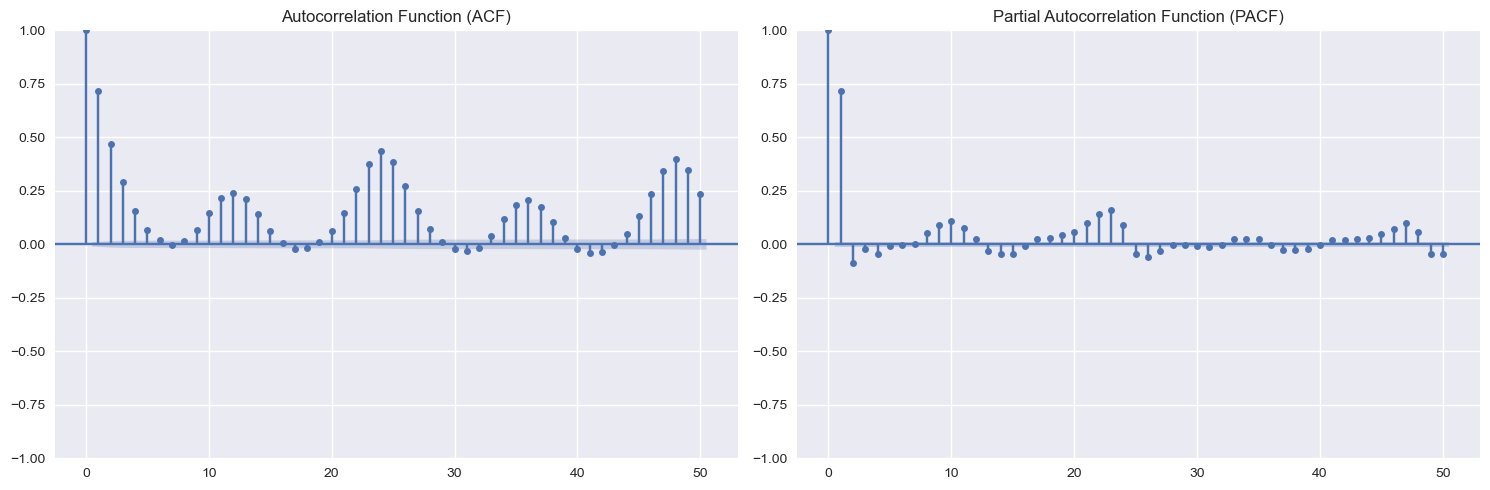

In [10]:
fig, ax = plt.subplots(1, 2, figsize=(15, 5))
plot_acf(ts, lags=50, ax=ax[0])
plot_pacf(ts, lags=50, ax=ax[1], method="ywm")

ax[0].set_title("Autocorrelation Function (ACF)")
ax[1].set_title("Partial Autocorrelation Function (PACF)")
plt.tight_layout()
plt.show()

## 🤖 7. Modeling: Manual ARIMA
We perform a grid search over potential values of `p` and `q` to find the ARIMA model that minimizes the **AIC (Akaike Information Criterion)**. The lower the AIC, the better the model fits the data while appropriately penalizing complexity.

> **💡 TIP: To save time and avoid re-running the grid search,**
> you can directly set the best order found in the previous run:
> best_order = (4, 0, 3)


In [11]:
if os.path.exists("manual_arima.pkl"):
    print("Loading saved Manual ARIMA model...")
    best_model = joblib.load("manual_arima.pkl")
else:
    print("Training Manual ARIMA model...")
    pq_candidates = [(p, q) for p in range(5) for q in range(4)]
    best_order = None
    best_aic = np.inf
    best_model = None
    for p, q in pq_candidates:
        try:
            model = ARIMA(train, order=(p, 0, q), enforce_stationarity=False, enforce_invertibility=False)
            fitted = model.fit()
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_order = (p, 0, q)
                best_model = fitted
        except Exception:
            continue
    print(f"Best ARIMA Order: {best_order}")
    print(f"Best AIC: {best_aic:.2f}")
    joblib.dump(best_model, "manual_arima.pkl")
    print("Model saved successfully!")

arima_pred = best_model.forecast(steps=len(test))
arima_mae = mean_absolute_error(test, arima_pred)
arima_rmse = np.sqrt(mean_squared_error(test, arima_pred))
arima_mape = mean_absolute_percentage_error(test, arima_pred)

print(f"MAE  : {arima_mae:.4f}")
print(f"RMSE : {arima_rmse:.4f}")
print(f"MAPE : {arima_mape:.4f}")
print(f"AIC  : {best_model.aic:.2f}")

Loading saved Manual ARIMA model...
MAE  : 0.5775
RMSE : 0.7011
MAPE : 0.9962
AIC  : 51775.82


Let's visualize how well the **Manual ARIMA** model forecasts the test period.

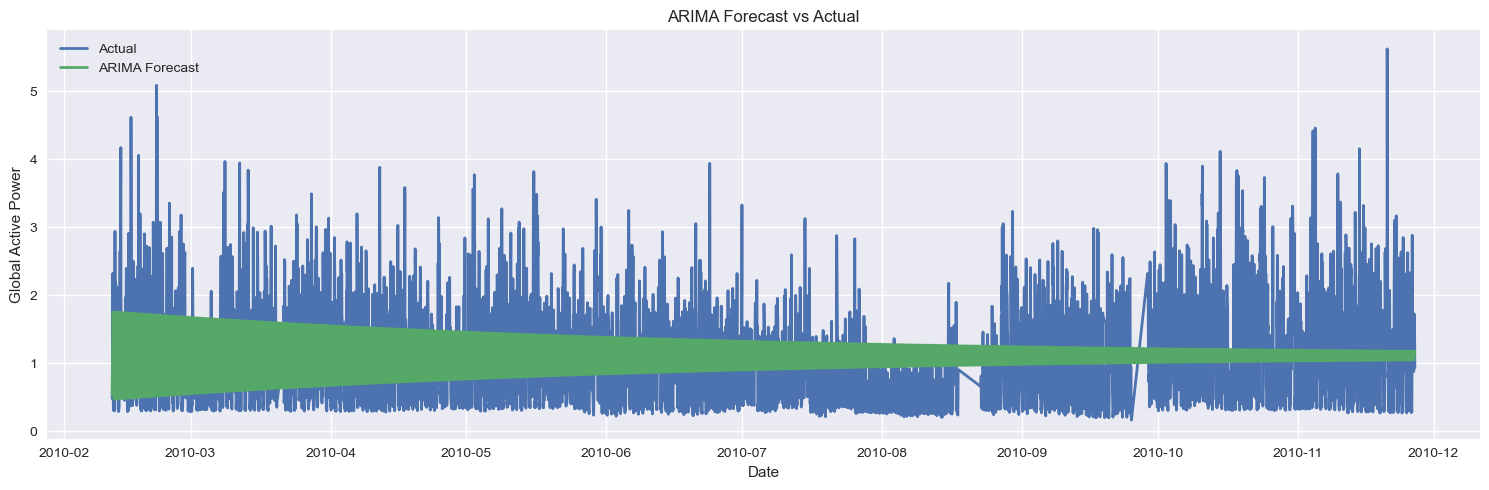

In [12]:
plt.figure(figsize=(15, 5))
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, arima_pred, label="ARIMA Forecast", linewidth=2)
plt.title("ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.tight_layout()
plt.show()

## ⚙️ 8. Modeling: Auto ARIMA
`pmdarima.auto_arima` automatically searches for the optimal parameters `(p, d, q)` within a specified range, saving us from manual grid searching and picking the configuration with the best AIC.

> **💡 TIP: To save time, you can comment out `auto_arima` below**
> and directly instantiate the ARIMA model with the best parameters:
> Best Auto ARIMA Order: (1, 0, 3)


In [13]:
if os.path.exists("auto_arima.pkl"):
    print("Loading saved Auto ARIMA model...")
    auto_model = joblib.load("auto_arima.pkl")
else:
    print("Training Auto ARIMA model...")
    auto_model = auto_arima(
        train,
        start_p=0,
        start_q=0,
        max_p=5,
        max_q=5,
        d=0,
        seasonal=False,
        stepwise=False,
        trace=True,
        error_action="ignore",
        suppress_warnings=True,
        information_criterion="aic",
        n_jobs=-1
    )
    joblib.dump(auto_model, "auto_arima.pkl")
    print("Model saved successfully!")

auto_pred = auto_model.predict(n_periods=len(test))
auto_mae = mean_absolute_error(test, auto_pred)
auto_rmse = np.sqrt(mean_squared_error(test, auto_pred))
auto_mape = mean_absolute_percentage_error(test, auto_pred)
print(f"MAE  : {auto_mae:.4f}")
print(f"RMSE : {auto_rmse:.4f}")
print(f"MAPE : {auto_mape:.4f}")
print(f"AIC  : {auto_model.aic():.2f}")

Loading saved Auto ARIMA model...
MAE  : 0.6241
RMSE : 0.7364
MAPE : 1.0858
AIC  : 53974.67


Let's plot the **Auto ARIMA** forecast.

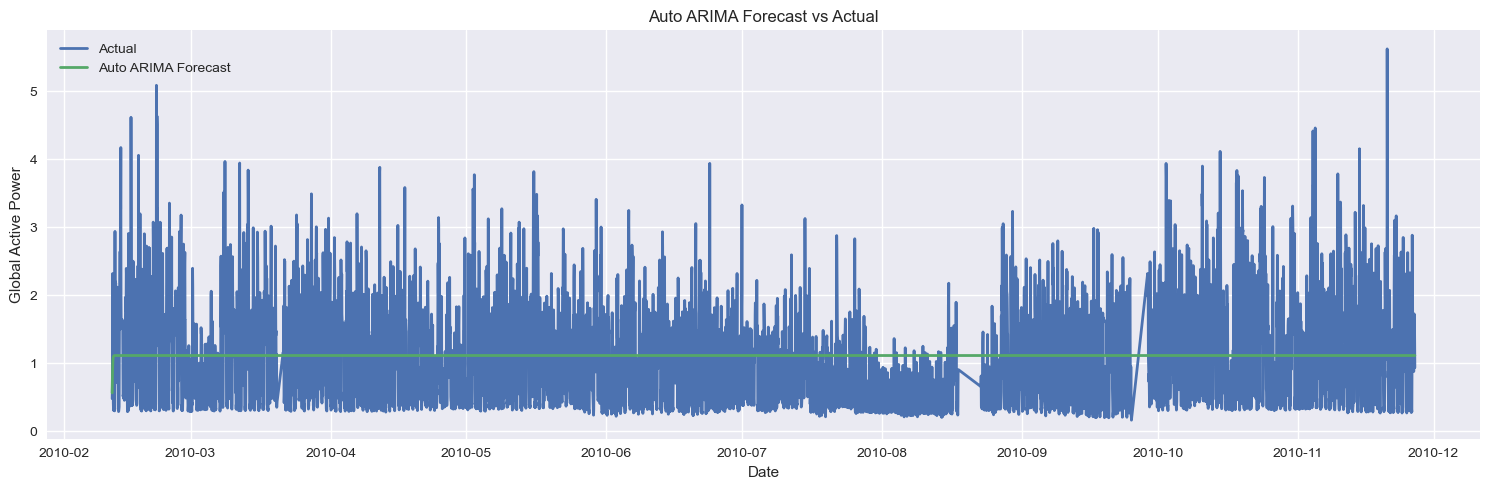

In [14]:
plt.figure(figsize=(15, 5))
plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, auto_pred, label="Auto ARIMA Forecast", linewidth=2)
plt.title("Auto ARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.tight_layout()
plt.show()

## ⛅ 9. Modeling: Seasonal ARIMA (SARIMA)
Since power consumption often exhibits seasonality (e.g., daily cycles where consumption drops at night and peaks during the day), we test a **SARIMA** model. SARIMA adds seasonal terms `(P, D, Q, s)` to the standard ARIMA model. Here we use a seasonal period `s=24` (as our data is hourly).

> **💡 TIP: To save time and avoid re-running this massive grid search,**
> you can directly set the best seasonal parameters if known:
> best_seasonal_order = (1, 0, 2, 24)  # Replace P and Q with your best


In [15]:
if os.path.exists("manual_sarima.pkl"):
    print("Loading saved Manual SARIMA model...")
    best_sarima = joblib.load("manual_sarima.pkl")
else:
    print("Training Manual SARIMA model...")
    seasonal_orders = [(P, Q) for P in range(4) for Q in range(4)]
    best_aic = np.inf
    best_seasonal_order = None
    best_sarima = None
    for P, Q in seasonal_orders:
        try:
            model = SARIMAX(train, order=(4, 0, 3), seasonal_order=(P, 0, Q, 24), enforce_stationarity=False,enforce_invertibility=False)
            fitted = model.fit(disp=False)
            if fitted.aic < best_aic:
                best_aic = fitted.aic
                best_seasonal_order = (P, 0, Q, 24)
                best_sarima = fitted
        except Exception:
            continue
    print("Best Seasonal Order:", best_seasonal_order)
    print("Best AIC:", best_aic)
    best_sarima.remove_data()
    joblib.dump(best_sarima, "manual_sarima.pkl")
    print("Model saved successfully!")

sarima_pred = best_sarima.forecast(steps=len(test))
sarima_mae = mean_absolute_error(test, sarima_pred)
sarima_rmse = np.sqrt(mean_squared_error(test, sarima_pred))
sarima_mape = mean_absolute_percentage_error(test, sarima_pred)

print(f"MAE  : {sarima_mae:.4f}")
print(f"RMSE : {sarima_rmse:.4f}")
print(f"MAPE : {sarima_mape:.4f}")
print(f"AIC  : {best_sarima.aic:.2f}")

Loading saved Manual SARIMA model...
MAE  : 0.5065
RMSE : 0.6832
MAPE : 0.7093
AIC  : 48235.51


Here's the visual comparison for **SARIMA**.

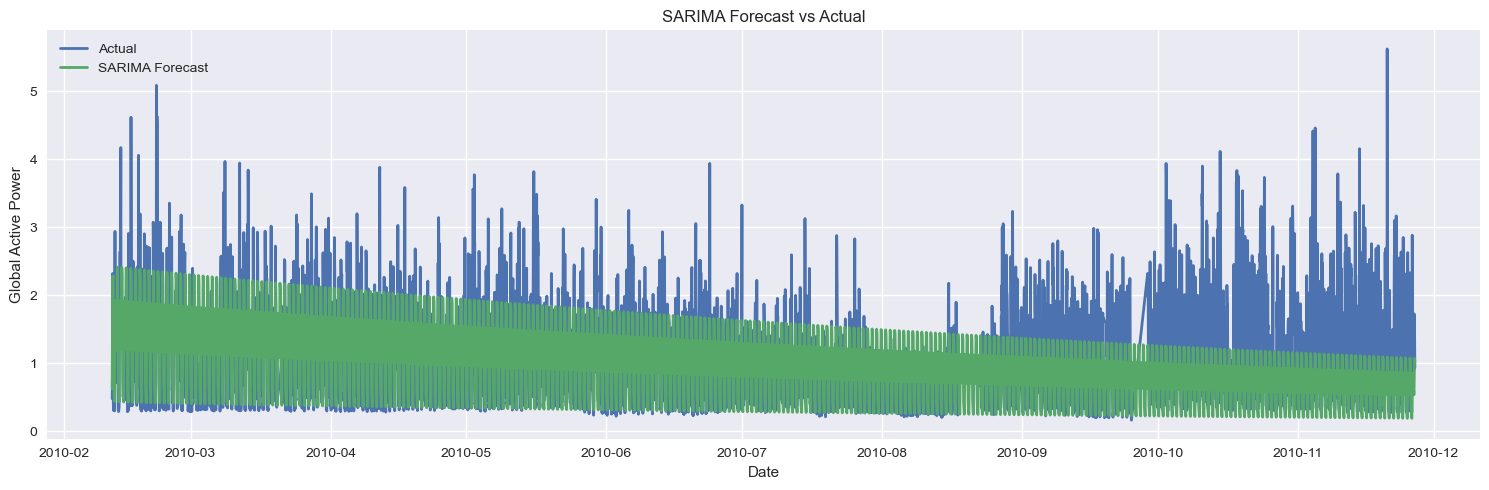

In [16]:
plt.figure(figsize=(15, 5))

plt.plot(test.index, test, label="Actual", linewidth=2)
plt.plot(test.index, sarima_pred, label="SARIMA Forecast", linewidth=2)

plt.title("SARIMA Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Global Active Power")

plt.legend()
plt.tight_layout()
plt.show()

## 🚀 10. Modeling: Meta Prophet
Prophet is a robust forecasting tool developed by Meta. It handles missing data and outliers well, and natively captures multiple seasonalities (daily, weekly, yearly) seamlessly.

In [17]:
if os.path.exists("prophet.pkl"):
    print("Loading saved Prophet model...")
    prophet_model = joblib.load("prophet.pkl")
else:
    print("Training Prophet model...")
    prophet_train = train.reset_index()
    prophet_train.columns = ["ds", "y"]
    prophet_model = Prophet(daily_seasonality=True, weekly_seasonality=True, yearly_seasonality=True)
    prophet_model.fit(prophet_train)
    joblib.dump(prophet_model, "prophet.pkl")
    print("Model saved successfully!")

future = prophet_model.make_future_dataframe(periods=len(test), freq="h")
forecast = prophet_model.predict(future)
prophet_pred = forecast["yhat"].tail(len(test)).values

prophet_mae = mean_absolute_error(test, prophet_pred)
prophet_rmse = np.sqrt(mean_squared_error(test, prophet_pred))
prophet_mape = mean_absolute_percentage_error(test, prophet_pred)
print(f"MAE  : {prophet_mae:.4f}")
print(f"RMSE : {prophet_rmse:.4f}")
print(f"MAPE : {prophet_mape:.4f}")

Training Prophet model...


02:03:54 - cmdstanpy - INFO - Chain [1] start processing
02:04:03 - cmdstanpy - INFO - Chain [1] done processing


Model saved successfully!
MAE  : 0.4884
RMSE : 0.6388
MAPE : 0.7337


Visualizing the **Prophet** forecast.

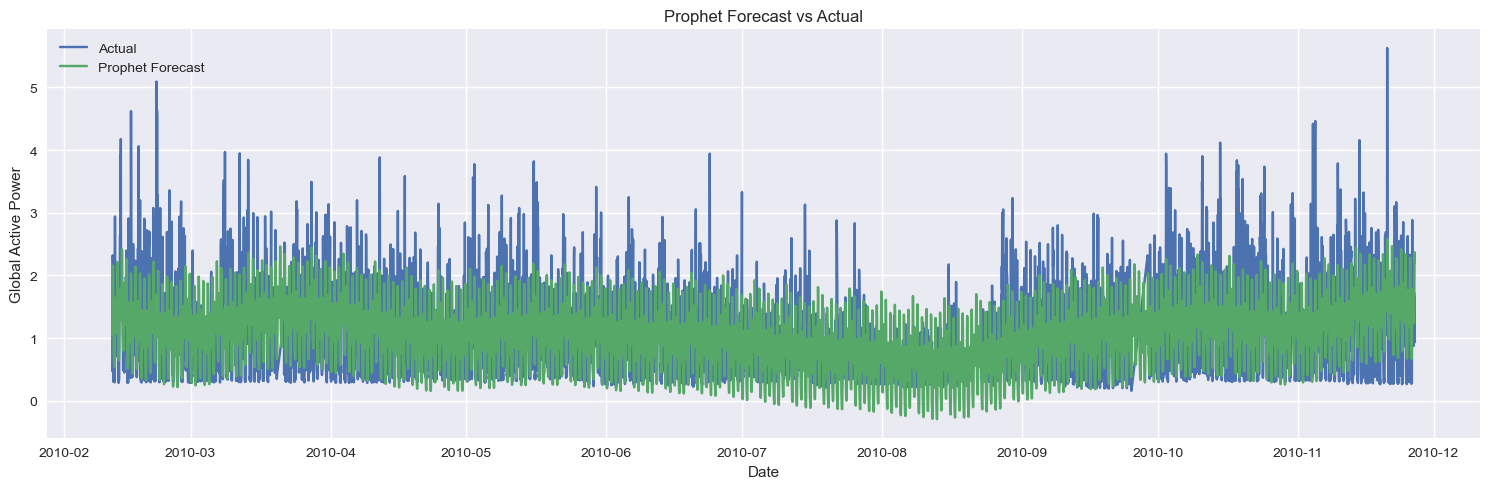

In [18]:
plt.figure(figsize=(15,5))
plt.plot(test.index, test, label="Actual")
plt.plot(test.index, prophet_pred, label="Prophet Forecast")
plt.title("Prophet Forecast vs Actual")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.legend()
plt.tight_layout()
plt.show()

## 🏆 11. Model Evaluation & Comparison
Let's compare all our trained models side-by-side using key performance metrics:
- **MAE** (Mean Absolute Error)
- **RMSE** (Root Mean Squared Error)
- **MAPE** (Mean Absolute Percentage Error)

We will sort them by **RMSE** (lower is better) to identify the best performing model.
> **Note:** Prophet doesn't calculate AIC internally like statsmodels, so it is shown as `NaN`.

In [19]:
comparison = pd.DataFrame({
    "Model": ["Manual ARIMA", "Auto ARIMA", "Manual SARIMA", "Prophet"],
    "AIC": [best_model.aic, auto_model.aic(), best_sarima.aic, np.nan],
    "MAE": [arima_mae, auto_mae, sarima_mae, prophet_mae],
    "RMSE": [arima_rmse, auto_rmse, sarima_rmse, prophet_rmse],
    "MAPE": [arima_mape, auto_mape, sarima_mape, prophet_mape]
})

comparison.sort_values("RMSE")

,Model,AIC,MAE,RMSE,MAPE
3,Prophet,NaN,0.488376,0.638814,0.733661
2,Manual SARIMA,48235.508059,0.506540,0.683244,0.709267
0,Manual ARIMA,51775.820707,0.577518,0.701146,0.996162
1,Auto ARIMA,53974.669380,0.624086,0.736408,1.085807


## 🔮 12. Future Forecasting (Next 24 Hours)
Using our overall **Best Model**, we will forecast the power consumption for the next 24 hours into the unknown future.

In [20]:
best_model_name = comparison.sort_values("RMSE").iloc[0]["Model"]
print("Best Model:", best_model_name)

if best_model_name == "Manual ARIMA":
    future_forecast = best_model.forecast(steps=24)
elif best_model_name == "Auto ARIMA":
    future_forecast = auto_model.predict(n_periods=24)
elif best_model_name == "Manual SARIMA":
    future_forecast = best_sarima.forecast(steps=24)
elif best_model_name == "Prophet":
    future = prophet_model.make_future_dataframe(periods=24, freq="h")
    forecast = prophet_model.predict(future)
    future_forecast = forecast["yhat"].tail(24).values

print(future_forecast)

Best Model: Prophet
[1.05311894 1.18086871 1.54858083 1.96485039 2.15846182 1.9918115
 1.5630312  1.10960787 0.81138935 0.67703162 0.605315   0.53776359
 0.53613307 0.70610179 1.05333122 1.43084332 1.64379283 1.61460087
 1.44516095 1.31262092 1.30160619 1.3402427  1.30278985 1.17151411]


Let's plot the 24-hour horizon.

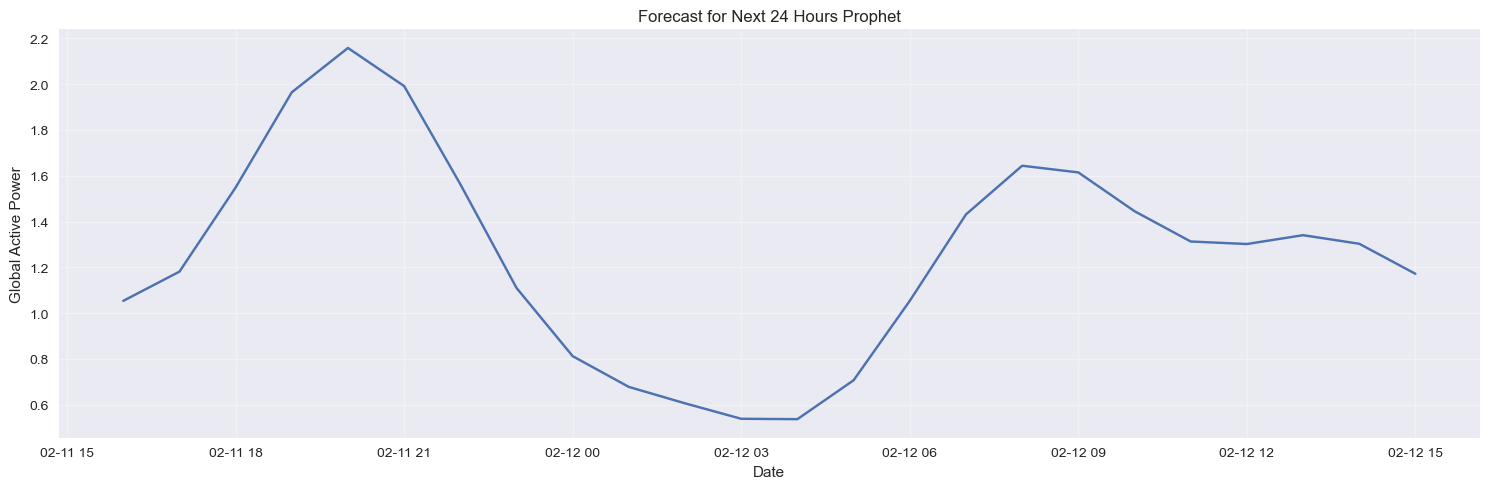

In [21]:
plt.figure(figsize=(15, 5))
if best_model_name == "Prophet":
    plt.plot(forecast["ds"].tail(24), future_forecast)
else:
    plt.plot(future_forecast.index, future_forecast)

plt.title(f"Forecast for Next 24 Hours {best_model_name}")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

## 📅 13. Future Forecasting (Next 7 Days)
We can extend our forecast window to a full week (168 hours) to observe the weekly pattern predicted by our best model.

In [22]:
if best_model_name == "Manual ARIMA":
    future_7d = best_model.forecast(steps=24*7)
elif best_model_name == "Auto ARIMA":
    future_7d = auto_model.predict(n_periods=24*7)
elif best_model_name == "Manual SARIMA":
    future_7d = best_sarima.forecast(steps=24*7)
elif best_model_name == "Prophet":
    future = prophet_model.make_future_dataframe(periods=24*7, freq="h")
    forecast = prophet_model.predict(future)
    future_7d = forecast.tail(24*7)[["ds", "yhat"]]

print(future_7d)

                       ds      yhat
27671 2010-02-11 16:00:00  1.053119
27672 2010-02-11 17:00:00  1.180869
27673 2010-02-11 18:00:00  1.548581
27674 2010-02-11 19:00:00  1.964850
27675 2010-02-11 20:00:00  2.158462
...                   ...       ...
27834 2010-02-18 11:00:00  1.098169
27835 2010-02-18 12:00:00  1.081982
27836 2010-02-18 13:00:00  1.115390
27837 2010-02-18 14:00:00  1.072620
27838 2010-02-18 15:00:00  0.935908

[168 rows x 2 columns]


Plotting the 7-day forecast horizon.

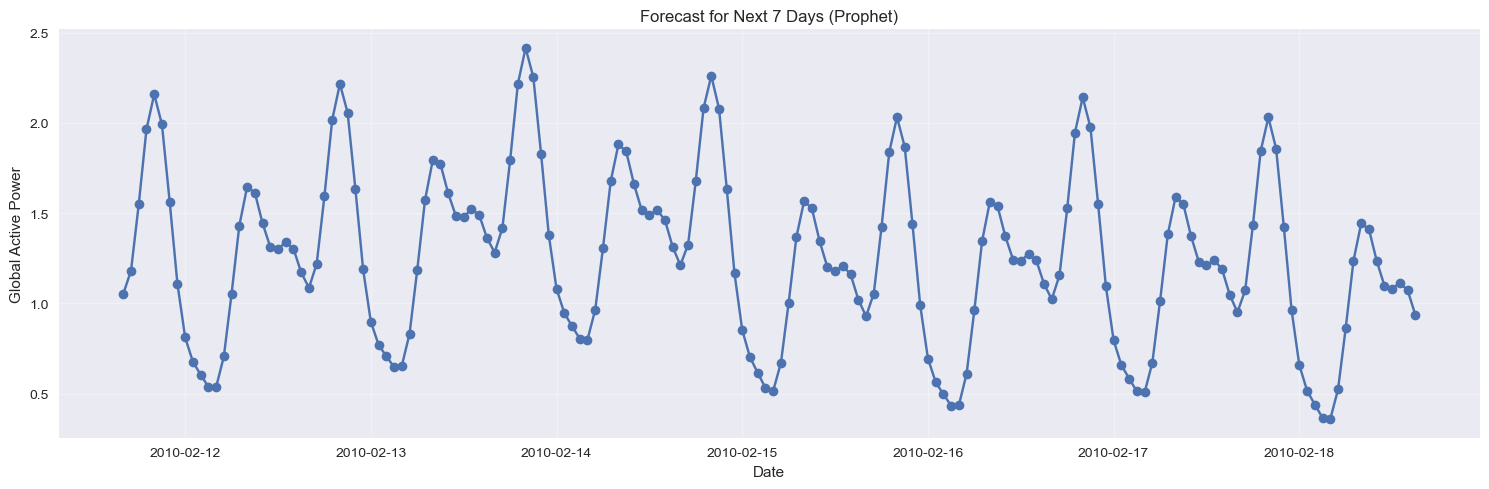

In [23]:
plt.figure(figsize=(15, 5))
if best_model_name == "Prophet":
    plt.plot(future_7d["ds"], future_7d["yhat"], marker="o")
else:
    plt.plot(future_7d.index, future_7d, marker="o")
    
plt.title(f"Forecast for Next 7 Days ({best_model_name})")
plt.xlabel("Date")
plt.ylabel("Global Active Power")
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

---
### 📌 Key Takeaways & Business Impact
- A reliable forecast of power consumption helps in **load balancing, dynamic pricing, and grid stability**.
- Seasonality is a massive factor; models that effectively capture daily and weekly cycles tend to perform significantly better on this dataset.